# Chapter 6 Demos

Runs the demo functions in `engineeringdynamicsdemos.ch6`.

The animation cells below are saved **unexecuted** (to keep this notebook small); run them to view the animations. The first animation cell sets `plt.rcParams["figure.dpi"] = 50`, which applies to all later animation cells.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
import warnings

from engineeringdynamicsdemos import ch6

## Pendulum on a Sliding Cart

See Example 6.2 and Problem 6.12. A pendulum attached to a cart that slides frictionlessly along $\mathbf{\hat{e}}_1$, with $\theta$ measured from $\mathbf{\hat{e}}_1$ towards $\mathbf{\hat{e}}_2$. The initial state is `y0 = [x, xdot, theta, thetadot]`. First, the cart starts at rest with the pendulum inverted at 45 degrees. Execute the following cell to view the animation. You can change the resolution of the generated figure by changing the time array `t` (duration and step) of the integration; longer/finer arrays take longer to render.

In [ ]:
plt.rcParams["figure.dpi"] = 50
anim = ch6.cart_pendulum_animation(t=np.arange(0, 15, 1 / 20), y0=[0, 0, np.pi / 4, 0])
plt.close(anim._fig)
HTML(anim.to_jshtml())

The cart starts at rest with the pendulum hanging down at 45 degrees:

In [ ]:
anim = ch6.cart_pendulum_animation(t=np.arange(0, 15, 1 / 20), y0=[0, 0, -np.pi / 4, 0])
plt.close(anim._fig)
HTML(anim.to_jshtml())

### The Vertical Unstable Equilibrium

With `upright=True` the cart starts at rest with the pendulum pointing straight up (`y0 = [0, 0, pi/2, 0]`). This is an equilibrium of the equations of motion, so the exact solution stays there forever. However, $\cos(\pi/2)$ evaluates to about $6\times 10^{-17}$ in floating point, rather than exactly zero, and every integrator adds its own truncation error. Since the equilibrium is unstable, these tiny errors grow until the pendulum falls.

The integrator is selected with `method` (any `scipy.integrate.solve_ivp` method) and its tolerances with `rtol`/`atol`. The defaults (`method="RK45"`, `rtol=1e-3`, `atol=1e-6`) correspond to MATLAB's `ode45` with its default tolerances. `DOP853` is the closest `solve_ivp` analog to MATLAB's `ode89`. Note that `solve_ivp` clips any `rtol` below about $2.2\times10^{-14}$ (100 times machine precision) to that value, with a warning.

The figure below compares $\theta(t)$ for several integrator/tolerance choices. Tightening the tolerance or switching to a higher-order method does not prevent the pendulum from falling. It only changes *when* the pendulum falls. The implicit `Radau` method is qualitatively different: its round-off happens to perturb $\theta$ by one unit in the last place on either side of $\pi/2$ rather than growing, so it stays upright. Adding an additional perturbation to the initial conditions (here, $10^{-12}$ rad) makes it fall too.

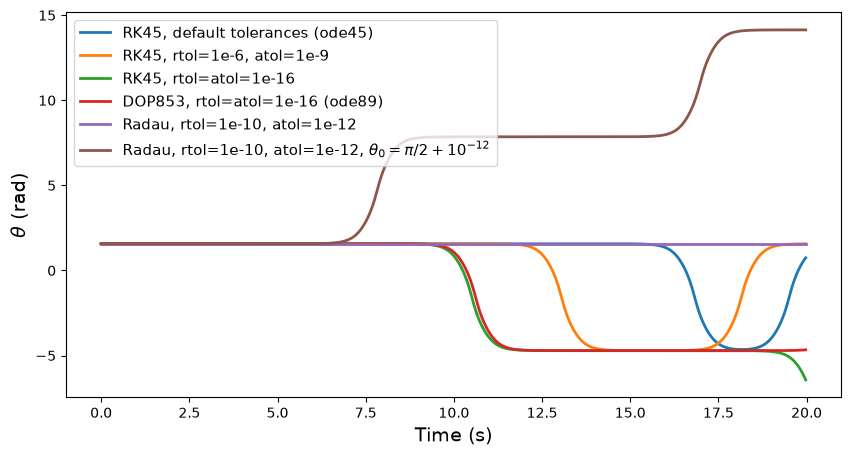

In [2]:
plt.rcParams["figure.dpi"] = 100

# solve_ivp warns that it clips rtol=1e-16 (see above); silence that here.
warnings.filterwarnings("ignore", message="At least one element of `rtol`")
t = np.arange(0, 20, 1 / 40)
variants = {
    "RK45, default tolerances (ode45)": dict(upright=True),
    "RK45, rtol=1e-6, atol=1e-9": dict(upright=True, rtol=1e-6, atol=1e-9),
    "RK45, rtol=atol=1e-16": dict(upright=True, rtol=1e-16, atol=1e-16),
    "DOP853, rtol=atol=1e-16 (ode89)": dict(
        upright=True, method="DOP853", rtol=1e-16, atol=1e-16
    ),
    "Radau, rtol=1e-10, atol=1e-12": dict(
        upright=True, method="Radau", rtol=1e-10, atol=1e-12
    ),
    r"Radau, rtol=1e-10, atol=1e-12, $\theta_0 = \pi/2 + 10^{-12}$": dict(
        y0=[0, 0, np.pi / 2 + 1e-12, 0], method="Radau", rtol=1e-10, atol=1e-12
    ),
}
fig, ax = plt.subplots(figsize=(10, 5))
for label, kwargs in variants.items():
    res = ch6.cart_pendulum_trajectory(t, **kwargs)
    ax.plot(t, res[:, 2], label=label, linewidth=2)
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel(r"$\theta$ (rad)", fontsize=14)
ax.legend(fontsize=11)
plt.show()

The following cells animate each of the integrator/tolerance variants shown above. You can change the resolution of the generated figure by changing the time array `t` (duration and step) of the integration; longer/finer arrays take longer to render.

In [ ]:
plt.rcParams["figure.dpi"] = 50
t = np.arange(0, 20, 1 / 20)
anim = ch6.cart_pendulum_animation(t=t, upright=True)
plt.close(anim._fig)
HTML(anim.to_jshtml())

In [ ]:
anim = ch6.cart_pendulum_animation(t=t, upright=True, rtol=1e-6, atol=1e-9)
plt.close(anim._fig)
HTML(anim.to_jshtml())

In [ ]:
anim = ch6.cart_pendulum_animation(t=t, upright=True, rtol=1e-16, atol=1e-16)
plt.close(anim._fig)
HTML(anim.to_jshtml())

In [ ]:
anim = ch6.cart_pendulum_animation(
    t=t, upright=True, method="DOP853", rtol=1e-16, atol=1e-16
)
plt.close(anim._fig)
HTML(anim.to_jshtml())

In [ ]:
anim = ch6.cart_pendulum_animation(
    t=t, upright=True, method="Radau", rtol=1e-10, atol=1e-12
)
plt.close(anim._fig)
HTML(anim.to_jshtml())

## Center of Mass Motion

See Section 6.1.3. Two identical clouds of particles, with their centers of mass drawn as large black dots and the centers' paths traced by dashed lines. On the left, all particles move with the same velocity, so there is no motion relative to the center of mass. On the right, every particle moves randomly relative to the others while the whole cloud drifts around a circle. The center of mass follows the circle smoothly anyway. `seed` makes the random cloud reproducible (omit it for a new cloud every time). Execute the following cell to view the animation. Reduce `n_steps` to shorten rendering time.

In [ ]:
anim = ch6.com_demo_animation(seed=0)
plt.close(anim._fig)
HTML(anim.to_jshtml())

## Particle Rebounding in a Box

A particle undergoing repeated collisions with the walls of a square box, with coefficient of restitution `e`. At each collision, the velocity component normal to the wall is reversed and scaled by `e`. The tangential component is unchanged. Execute the following cells to view the animations. Rendering time scales with the number of frames: `fps` frames per second of simulated time, which grows quickly with `n_bounces` for `e < 1` as the particle slows down.

With `e = 1` there is no energy loss:

In [ ]:
anim = ch6.rebound_box_animation(e=1)
plt.close(anim._fig)
HTML(anim.to_jshtml())

`e = 0.8`:

In [ ]:
anim = ch6.rebound_box_animation(e=0.8, n_bounces=12, fps=15)
plt.close(anim._fig)
HTML(anim.to_jshtml())

`e = 0.1`:

In [ ]:
anim = ch6.rebound_box_animation(e=0.1, n_bounces=4, fps=15)
plt.close(anim._fig)
HTML(anim.to_jshtml())